# 10 Unsupervised PC Regression

1. Apply same variance filter as NB07 (top 20K genes) — apples-to-apples comparison
2. For each CV fold, fit PCA on **training data only** → extract top 800 PCs
3. Within the fold, AUC-select the top 100 PCs (train only)
4. Train RF on selected PCs → predict on test fold

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

from gtex_biomarkers.config import Config
from gtex_biomarkers.data import load_cache, build_confounder_matrix, variance_filter
from gtex_biomarkers.labels import discover_tissue_category_pairs, assign_donor_labels
from gtex_biomarkers.models import make_rf_model, _auc_feature_selection
from gtex_biomarkers.evaluation import plot_paired_auc_bar, plot_delta_bar

Config.ensure_dirs()

# Load data
X_wb, blood_subjid, _, df_meta_url, df_age = load_cache()
rf_summary = pd.read_csv(Config.TABLES_DIR / 'cv_results_all_tissue_rf.csv')
three_way = pd.read_csv(Config.TABLES_DIR / 'cv_three_way_comparison.csv')

# Variance filter — same top 20K genes as NB07 (apples-to-apples)
X_wb_var, gene_var = variance_filter(X_wb)
print(f'Variance filter: {X_wb.shape[1]:,} → {X_wb_var.shape[1]:,} genes')

# Build confounder matrix (same as NB09)
X_conf = build_confounder_matrix(df_age, blood_subjid)

print(f'Expression matrix: {X_wb_var.shape[0]} samples x {X_wb_var.shape[1]:,} genes')
print(f'Confounder matrix: {X_conf.shape[0]} samples x {X_conf.shape[1]} features ({list(X_conf.columns)})')

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes
Variance filter: 59,033 → 20,000 genes
Expression matrix: 803 samples x 20,000 genes
Confounder matrix: 803 samples x 5 features (['SEX', 'AGE', 'RACE', 'DTHHRDY', 'TRISCHD'])


## 10.1 — Global PCA Sanity Check

How much variance do the top 800 PCs capture from the 20K variance-filtered genes?

Top 800 PCs explain 100.0% of total variance
Top 100 PCs explain 84.3%
Top 10 PCs explain 62.7%


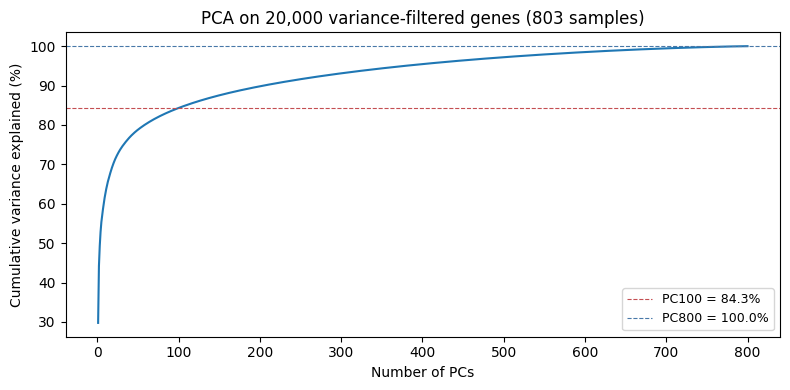

In [2]:
N_PCS = 800  
TOP_K_PCS = 100

# Quick exploratory PCA on variance-filtered genes
scaler_check = StandardScaler()
X_scaled_check = scaler_check.fit_transform(X_wb_var)
n_comp_check = min(N_PCS, X_scaled_check.shape[0] - 1, X_scaled_check.shape[1])
pca_check = PCA(n_components=n_comp_check, random_state=Config.SEED)
pca_check.fit(X_scaled_check)

cum_var = np.cumsum(pca_check.explained_variance_ratio_)
print(f'Top {n_comp_check} PCs explain {cum_var[-1]*100:.1f}% of total variance')
print(f'Top 100 PCs explain {cum_var[99]*100:.1f}%')
print(f'Top 10 PCs explain {cum_var[9]*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_comp_check + 1), cum_var * 100, lw=1.5)
ax.axhline(cum_var[99] * 100, color='#C44E52', ls='--', lw=0.8, label=f'PC100 = {cum_var[99]*100:.1f}%')
ax.axhline(cum_var[-1] * 100, color='#4878A8', ls='--', lw=0.8, label=f'PC{n_comp_check} = {cum_var[-1]*100:.1f}%')
ax.set(xlabel='Number of PCs', ylabel='Cumulative variance explained (%)',
       title=f'PCA on {X_wb_var.shape[1]:,} variance-filtered genes ({X_wb_var.shape[0]} samples)')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / 'pca_cumulative_variance_global.pdf', bbox_inches='tight')
plt.show()

del scaler_check, X_scaled_check, pca_check

## 10.1b — Sanity Check: Normalization Properties

Two properties must hold for clean gene-level importance (NB11):

1. **RF Gini importances** sum to 1 across all features — but when we slice PCs only (drop confounders), the sum < 1. We renormalize so PCs sum to 1.
2. **PCA absolute loadings** — `Σ_j |loading(i,j)| ≠ 1` per PC. We normalize so each PC distributes exactly 100% of its importance across genes.

In [ ]:
# Re-fit a quick PCA for the sanity check (same as 10.1)
scaler_sc = StandardScaler()
X_sc = scaler_sc.fit_transform(X_wb_var)
pca_sc = PCA(n_components=min(N_PCS, X_sc.shape[0] - 1), random_state=Config.SEED)
pca_sc.fit(X_sc)

# --- Sanity Check 1: RF Gini importance sums ---
# Train a quick RF on PCs + confounders for Liver|cirrhosis to demonstrate
y_sc, _, _, _ = assign_donor_labels(df_meta_url, 'Liver', 'cirrhosis', blood_subjid)
keep_sc = y_sc.notna()
y_sc_clean = y_sc[keep_sc].astype(int)
X_sc_sub = scaler_sc.transform(X_wb_var.loc[keep_sc])
X_pcs_sc = pca_sc.transform(X_sc_sub)

pc_cols_sc = [f'PC{i+1}' for i in range(pca_sc.n_components_)]
X_pcs_df = pd.DataFrame(X_pcs_sc, columns=pc_cols_sc, index=X_wb_var.loc[keep_sc].index)

top_pcs_sc = _auc_feature_selection(X_pcs_df, y_sc_clean, top_k=TOP_K_PCS)
X_sel = pd.concat([X_pcs_df[top_pcs_sc], X_conf.loc[keep_sc]], axis=1)

rf_sc = make_rf_model()
rf_sc.fit(X_sel, y_sc_clean)

fi_all = rf_sc.feature_importances_
fi_pcs = fi_all[:len(top_pcs_sc)]
fi_conf = fi_all[len(top_pcs_sc):]

print('=== Sanity Check 1: RF Gini Importance Sums ===')
print(f'  Total (all {len(fi_all)} features):  {fi_all.sum():.6f}  (should be 1.0)')
print(f'  PCs only ({len(fi_pcs)} features):   {fi_pcs.sum():.6f}  (< 1, confounders absorbed {fi_conf.sum():.4f})')
print(f'  After renorm PCs to 1:     {(fi_pcs / fi_pcs.sum()).sum():.6f}')
print()

# --- Sanity Check 2: Absolute loading norms per PC ---
pc_idx = 0
loadings_pc1 = pca_sc.components_[pc_idx, :]

abs_sum = np.sum(np.abs(loadings_pc1))
abs_norm_sum = np.sum(np.abs(loadings_pc1) / abs_sum)

print('=== Sanity Check 2: Absolute Loading Norms (PC1) ===')
print(f'  Σ |loading|:      {abs_sum:.4f}  (>> 1, not normalized)')
print(f'  After |L|/Σ|L|:   {abs_norm_sum:.6f}  (= 1.0 after normalization)')
del scaler_sc, X_sc, pca_sc, rf_sc

=== Sanity Check 1: RF Gini Importance Sums ===
  Total (all 105 features):  1.000000  (should be 1.0)
  PCs only (100 features):   0.988870  (< 1, confounders absorbed 0.0111)
  After renorm PCs to 1:     1.000000

=== Sanity Check 2: Absolute Loading Norms (PC1) ===
  Σ |loading|:      126.5693  (>> 1, not normalized)
  After |L|/Σ|L|:   1.000000  (= 1.0 after normalization)

→ In NB11: normalize |loadings| per PC so each PC distributes
  exactly 100% of its RF importance across genes.


In [4]:
def run_cv_with_pca(X, y, groups, n_pcs=1000, top_k_pcs=100, X_conf_sub=None, cfg=None, tag=''):
    """Leak-free CV: PCA fit inside each fold on training data only.
    
    If X_conf_sub is provided, confounders are appended to the selected PCs
    before training the RF (PCs + confounders model).
    """
    cfg = cfg or Config
    cv = StratifiedGroupKFold(
        n_splits=cfg.N_SPLITS, shuffle=True, random_state=cfg.SEED
    )

    oof = np.full(len(y), np.nan)
    fold_aucs = []

    for fold, (tr, te) in enumerate(cv.split(X, y, groups=groups), 1):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]

        # Fit scaler + PCA on training data
        scaler = StandardScaler()
        Xtr_scaled = scaler.fit_transform(Xtr)
        Xte_scaled = scaler.transform(Xte)

        n_comp = min(n_pcs, Xtr_scaled.shape[0] - 1, Xtr_scaled.shape[1])
        pca = PCA(n_components=n_comp, random_state=cfg.SEED)
        Xtr_pcs = pca.fit_transform(Xtr_scaled)
        Xte_pcs = pca.transform(Xte_scaled)

        # Convert to DataFrame for AUC feature selection
        pc_cols = [f'PC{i+1}' for i in range(n_comp)]
        Xtr_pcs = pd.DataFrame(Xtr_pcs, columns=pc_cols, index=Xtr.index)
        Xte_pcs = pd.DataFrame(Xte_pcs, columns=pc_cols, index=Xte.index)

        # AUC-select top PCs on training data
        top_pcs = _auc_feature_selection(Xtr_pcs, ytr, top_k=min(top_k_pcs, n_comp))

        # Subset to selected PCs
        Xtr_sel = Xtr_pcs[top_pcs]
        Xte_sel = Xte_pcs[top_pcs]

        # Append confounders if provided
        if X_conf_sub is not None:
            Xtr_sel = pd.concat([Xtr_sel, X_conf_sub.iloc[tr]], axis=1)
            Xte_sel = pd.concat([Xte_sel, X_conf_sub.iloc[te]], axis=1)

        # Train RF
        model = make_rf_model()
        model.fit(Xtr_sel, ytr)
        proba = model.predict_proba(Xte_sel)[:, 1]
        oof[te] = proba

        fauc = roc_auc_score(yte, proba)
        fold_aucs.append(fauc)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    print(f'    {tag} Mean AUC = {mean_auc:.3f} +/- {std_auc:.3f}')
    return {'mean_auc': mean_auc, 'std_auc': std_auc, 'fold_aucs': fold_aucs, 'oof': oof, 'y': y}

## 10.2 — Single-Feature AUC: Liver | Cirrhosis

For Liver | cirrhosis, fit PCA on 20K variance-filtered genes → 800 PCs, then
compute the **univariate AUC** of each PC individually against the label.

Liver | cirrhosis: 49 positive, 368 negative, 417 total

Top 10 PCs by univariate AUC:
  1. PC1: AUC = 0.710
  2. PC13: AUC = 0.690
  3. PC7: AUC = 0.682
  4. PC416: AUC = 0.666
  5. PC4: AUC = 0.661
  6. PC18: AUC = 0.649
  7. PC64: AUC = 0.635
  8. PC10: AUC = 0.623
  9. PC47: AUC = 0.621
  10. PC51: AUC = 0.618

PCs with AUC > 0.55: 136 / 416
PCs with AUC > 0.60: 20 / 416


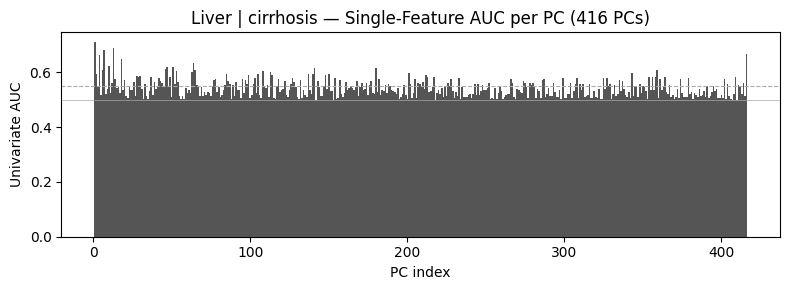

In [5]:
# Prepare Liver | cirrhosis labels
y_demo, _, n_pos_demo, n_neg_demo = assign_donor_labels(
    df_meta_url, 'Liver', 'cirrhosis', blood_subjid
)
keep_demo = y_demo.notna()
y_demo_clean = y_demo[keep_demo].astype(int)
X_demo = X_wb_var.loc[keep_demo]
print(f'Liver | cirrhosis: {n_pos_demo} positive, {n_neg_demo} negative, {len(y_demo_clean)} total')

# Fit PCA on this subset
scaler_demo = StandardScaler()
X_demo_scaled = scaler_demo.fit_transform(X_demo)
n_comp_demo = min(N_PCS, X_demo_scaled.shape[0] - 1, X_demo_scaled.shape[1])
pca_demo = PCA(n_components=n_comp_demo, random_state=Config.SEED)
X_demo_pcs = pca_demo.fit_transform(X_demo_scaled)

# Univariate AUC: each PC vs label independently
pc_aucs = []
for i in range(n_comp_demo):
    auc_i = roc_auc_score(y_demo_clean, X_demo_pcs[:, i])
    # Flip if below 0.5 (direction doesn't matter for univariate screening)
    pc_aucs.append(max(auc_i, 1 - auc_i))

pc_aucs = np.array(pc_aucs)
top_idx = np.argsort(pc_aucs)[::-1]

print(f'\nTop 10 PCs by univariate AUC:')
for rank, idx in enumerate(top_idx[:10], 1):
    print(f'  {rank}. PC{idx+1}: AUC = {pc_aucs[idx]:.3f}')

print(f'\nPCs with AUC > 0.55: {(pc_aucs > 0.55).sum()} / {n_comp_demo}')
print(f'PCs with AUC > 0.60: {(pc_aucs > 0.60).sum()} / {n_comp_demo}')

# Plot: univariate AUC per PC (sorted by PC index)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(1, n_comp_demo + 1), pc_aucs, color='#555555', width=1.0)
ax.axhline(0.5, ls='-', lw=0.5, color='#AAAAAA')
ax.axhline(0.55, ls='--', lw=0.8, color='#AAAAAA')
ax.set_xlabel('PC index')
ax.set_ylabel('Univariate AUC')
ax.set_title(f'Liver | cirrhosis — Single-Feature AUC per PC ({n_comp_demo} PCs)')
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / 'liver_cirrhosis_univariate_pc_auc.pdf', bbox_inches='tight')
plt.show()

del scaler_demo, X_demo_scaled, pca_demo, X_demo_pcs

## 10.3 — Run All 53 Pairs

Leak-free PC-based CV on all tissue × pathology pairs (20K variance-filtered genes).

In [6]:
pairs_df = discover_tissue_category_pairs(df_meta_url)
print(f'{len(pairs_df)} tissue x category pairs\n')

pc_results = []
for i, (_, pair) in enumerate(pairs_df.iterrows()):
    tissue, cat = pair['tissue'], pair['category']
    tag = f'{tissue} | {cat}'

    y, _, n_pos, n_neg = assign_donor_labels(df_meta_url, tissue, cat, blood_subjid)
    keep = y.notna()
    y_clean = y[keep].astype(int)
    g = blood_subjid[keep].astype(str)
    X_sub = X_wb_var.loc[keep]  # variance-filtered 20K genes

    if n_pos < Config.MIN_POS_NEG_BLOOD or n_neg < Config.MIN_POS_NEG_BLOOD:
        continue

    print(f'[{i+1:2d}/{len(pairs_df)}] {tag}  (n_pos={n_pos}, n_neg={n_neg})')
    res = run_cv_with_pca(X_sub, y_clean, g, n_pcs=N_PCS, top_k_pcs=TOP_K_PCS, tag=tag)
    pc_results.append({'tissue': tissue, 'category': cat, 'auc_pc': res['mean_auc'],
                       'std_pc': res['std_auc']})

pc_auc = pd.DataFrame(pc_results)
print(f'Completed {len(pc_auc)} models')
print(f'Mean PC AUC across all models: {pc_auc["auc_pc"].mean():.3f}')

53 tissue x category pairs

[ 1/53] Adipose - Subcutaneous | fibrosis  (n_pos=118, n_neg=30)
    Adipose - Subcutaneous | fibrosis Mean AUC = 0.557 +/- 0.121
[ 2/53] Adipose - Visceral (Omentum) | fibrosis  (n_pos=87, n_neg=49)
    Adipose - Visceral (Omentum) | fibrosis Mean AUC = 0.474 +/- 0.076
[ 3/53] Artery - Aorta | atherosis  (n_pos=187, n_neg=154)
    Artery - Aorta | atherosis Mean AUC = 0.462 +/- 0.056
[ 4/53] Artery - Aorta | atherosclerosis  (n_pos=88, n_neg=253)
    Artery - Aorta | atherosclerosis Mean AUC = 0.485 +/- 0.082
[ 5/53] Artery - Aorta | sclerotic  (n_pos=55, n_neg=286)
    Artery - Aorta | sclerotic Mean AUC = 0.500 +/- 0.105
[ 6/53] Artery - Aorta | calcification  (n_pos=41, n_neg=300)
    Artery - Aorta | calcification Mean AUC = 0.591 +/- 0.068
[ 7/53] Artery - Coronary | calcification  (n_pos=127, n_neg=162)
    Artery - Coronary | calcification Mean AUC = 0.520 +/- 0.059
[ 8/53] Artery - Coronary | atherosclerosis  (n_pos=122, n_neg=167)
    Artery - Coro

## 10.4 — Liver | Cirrhosis in Context

Where does the Liver | cirrhosis pair rank among all 53 models?

In [7]:
pc_auc_sorted = pc_auc.copy()
pc_auc_sorted['label'] = pc_auc_sorted['tissue'] + ' | ' + pc_auc_sorted['category']
pc_auc_sorted = pc_auc_sorted.sort_values('auc_pc', ascending=False).reset_index(drop=True)

rank = pc_auc_sorted[pc_auc_sorted['label'] == 'Liver | cirrhosis'].index[0] + 1
auc_val = pc_auc_sorted.loc[pc_auc_sorted['label'] == 'Liver | cirrhosis', 'auc_pc'].values[0]
print(f'Liver | cirrhosis PC AUC: {auc_val:.3f}  (rank {rank}/{len(pc_auc_sorted)})')

Liver | cirrhosis PC AUC: 0.780  (rank 2/53)


## 10.5 — PC AUC Bar Chart

Horizontal bar chart of PC-based AUC for all 53 tissue × pathology pairs, sorted by AUC.

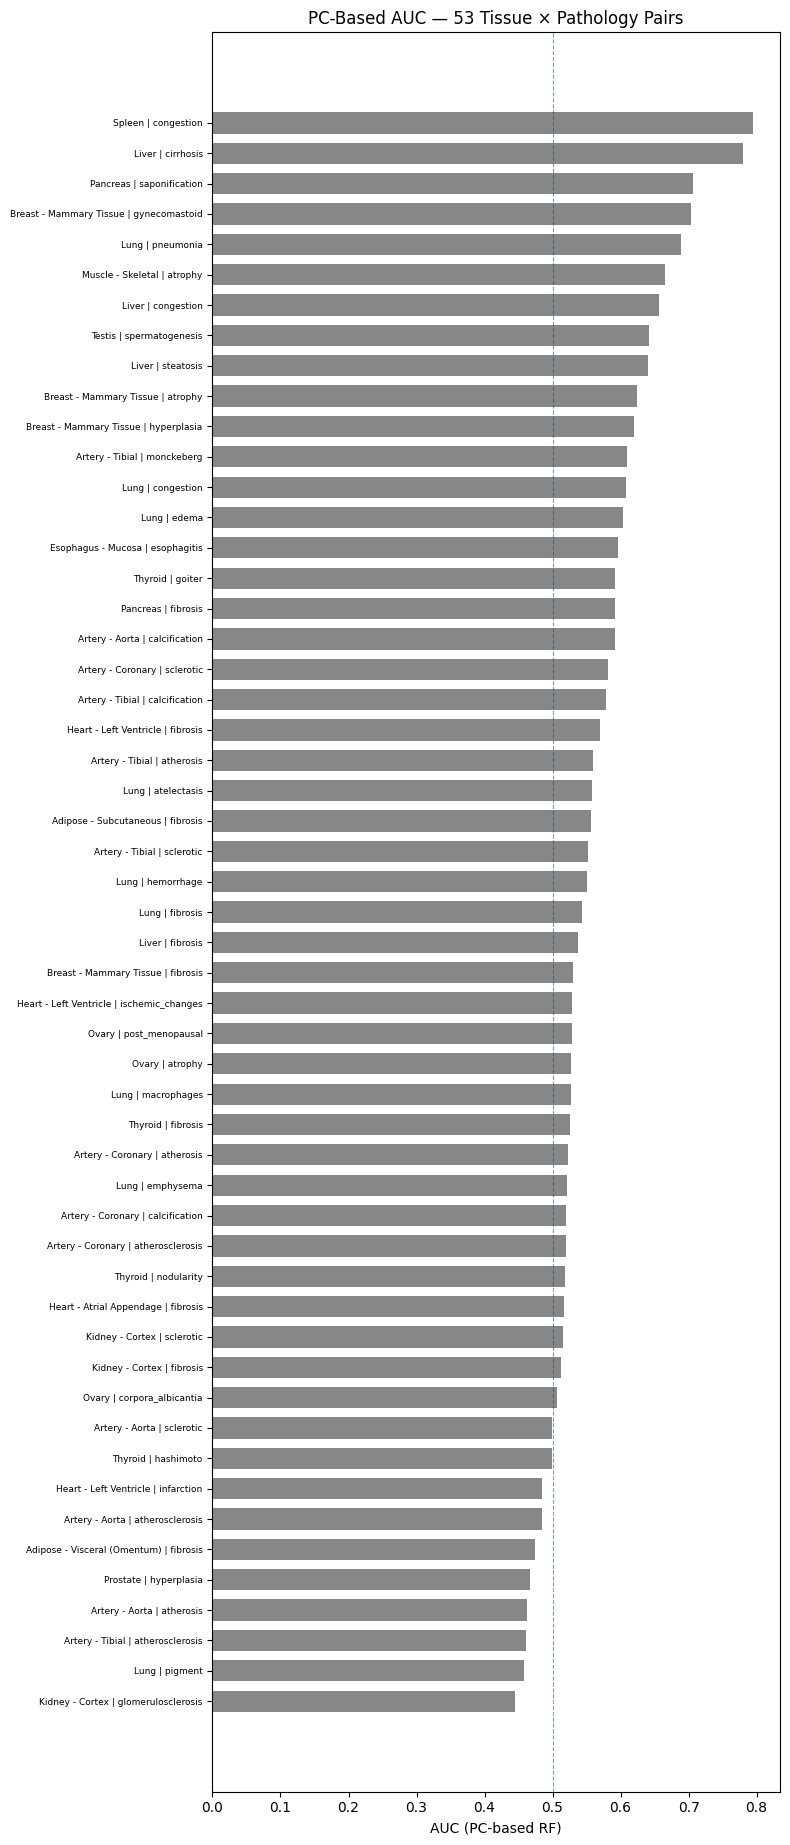

In [16]:
plot_df = pc_auc.copy()
plot_df['label'] = plot_df['tissue'] + ' | ' + plot_df['category']
plot_df = plot_df.sort_values('auc_pc', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, max(10, len(plot_df) * 0.35)))
ax.barh(range(len(plot_df)), plot_df['auc_pc'], color='#555555', height=0.7, alpha=0.7)
ax.axvline(0.5, ls='--', lw=0.8, color="#13527E92")
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'], fontsize=6.5)
ax.set_xlabel('AUC (PC-based RF)')
ax.set_title('PC-Based AUC — 53 Tissue × Pathology Pairs')
fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / 'pc_auc_bar.pdf', bbox_inches='tight')
plt.show()

## 10.6 — PC + Confounders (All Pairs)

Same leak-free CV as 10.3, but confounders (SEX, AGE, RACE, DTHHRDY, TRISCHD) are
appended to the selected PCs before training the RF.

In [9]:
pc_conf_results = []
for i, (_, pair) in enumerate(pairs_df.iterrows()):
    tissue, cat = pair['tissue'], pair['category']
    tag = f'{tissue} | {cat}'

    y, _, n_pos, n_neg = assign_donor_labels(df_meta_url, tissue, cat, blood_subjid)
    keep = y.notna()
    y_clean = y[keep].astype(int)
    g = blood_subjid[keep].astype(str)
    X_sub = X_wb_var.loc[keep]  # variance-filtered 20K genes
    X_conf_sub = X_conf.loc[keep]

    if n_pos < Config.MIN_POS_NEG_BLOOD or n_neg < Config.MIN_POS_NEG_BLOOD:
        continue

    print(f'[{i+1:2d}/{len(pairs_df)}] {tag}  (n_pos={n_pos}, n_neg={n_neg})')
    res = run_cv_with_pca(X_sub, y_clean, g, n_pcs=N_PCS, top_k_pcs=TOP_K_PCS,
                          X_conf_sub=X_conf_sub, tag=tag)
    pc_conf_results.append({'tissue': tissue, 'category': cat,
                            'auc_pc_conf': res['mean_auc'], 'std_pc_conf': res['std_auc']})

pc_conf_auc = pd.DataFrame(pc_conf_results)
print(f'\nCompleted {len(pc_conf_auc)} PC+Conf models')
print(f'Mean PC+Conf AUC: {pc_conf_auc["auc_pc_conf"].mean():.3f}')

[ 1/53] Adipose - Subcutaneous | fibrosis  (n_pos=118, n_neg=30)
    Adipose - Subcutaneous | fibrosis Mean AUC = 0.577 +/- 0.096
[ 2/53] Adipose - Visceral (Omentum) | fibrosis  (n_pos=87, n_neg=49)
    Adipose - Visceral (Omentum) | fibrosis Mean AUC = 0.469 +/- 0.093
[ 3/53] Artery - Aorta | atherosis  (n_pos=187, n_neg=154)
    Artery - Aorta | atherosis Mean AUC = 0.473 +/- 0.041
[ 4/53] Artery - Aorta | atherosclerosis  (n_pos=88, n_neg=253)
    Artery - Aorta | atherosclerosis Mean AUC = 0.495 +/- 0.069
[ 5/53] Artery - Aorta | sclerotic  (n_pos=55, n_neg=286)
    Artery - Aorta | sclerotic Mean AUC = 0.479 +/- 0.089
[ 6/53] Artery - Aorta | calcification  (n_pos=41, n_neg=300)
    Artery - Aorta | calcification Mean AUC = 0.589 +/- 0.081
[ 7/53] Artery - Coronary | calcification  (n_pos=127, n_neg=162)
    Artery - Coronary | calcification Mean AUC = 0.549 +/- 0.046
[ 8/53] Artery - Coronary | atherosclerosis  (n_pos=122, n_neg=167)
    Artery - Coronary | atherosclerosis Mean 

## 10.7 — Comparison: PC+Conf vs Conf-only

Side-by-side bar chart showing PC+Conf AUC vs Conf-only AUC (from NB09).
This shows how much the PCs add on top of demographics.

Mean Conf-only AUC: 0.556
Mean PC+Conf AUC:   0.582


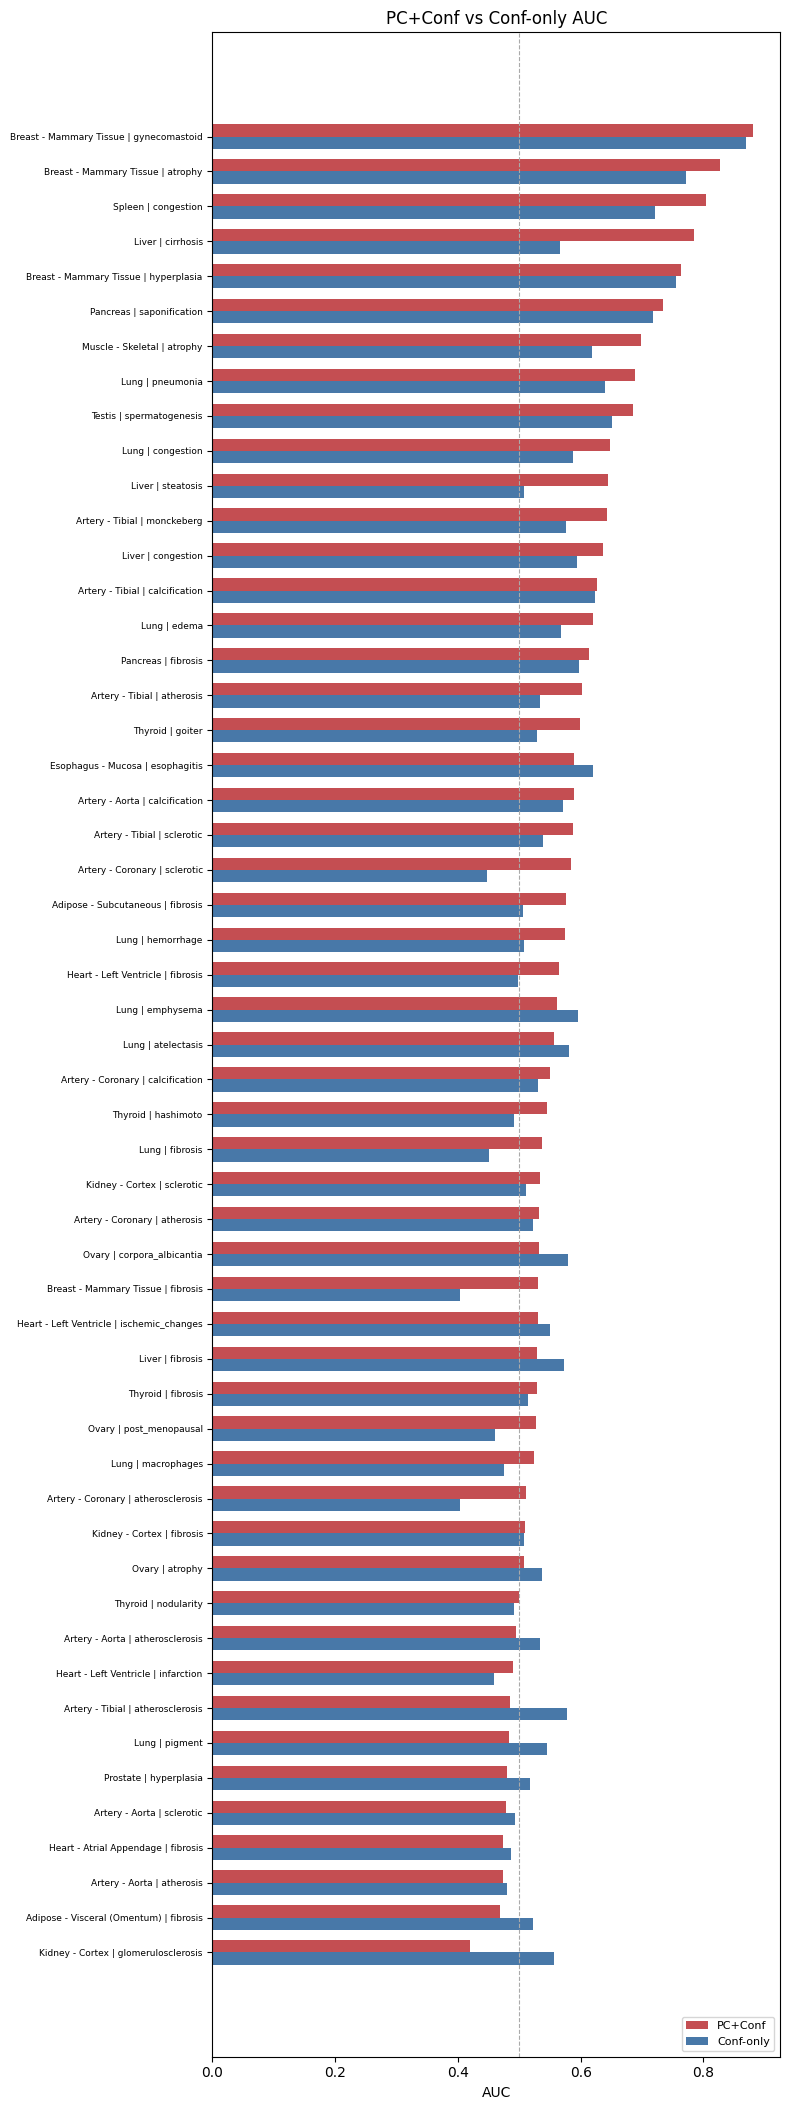

In [10]:
# Merge PC+Conf with conf-only AUC from three_way (NB09)
comp = pc_conf_auc.merge(
    three_way[['tissue', 'category', 'auc_conf']],
    on=['tissue', 'category']
)
comp = comp.merge(pc_auc, on=['tissue', 'category'])
comp['delta_pc'] = comp['auc_pc_conf'] - comp['auc_conf']

print(f'Mean Conf-only AUC: {comp["auc_conf"].mean():.3f}')
print(f'Mean PC+Conf AUC:   {comp["auc_pc_conf"].mean():.3f}')

_ = plot_paired_auc_bar(
    comp, auc_col_a='auc_pc_conf', auc_col_b='auc_conf',
    label_a='PC+Conf', label_b='Conf-only',
    title='PC+Conf vs Conf-only AUC',
    save_path=Config.FIGURES_DIR / 'pc_conf_vs_conf_bar.pdf'
)

## 10.8 — ΔAUC: PC Gain Over Confounders

**Δ = AUC(PC+Conf) − AUC(Conf-only)**

How much do PCs add beyond demographics alone? Uses conf-only AUC from NB09.

Mean Δ (PC gain over conf): 0.0263


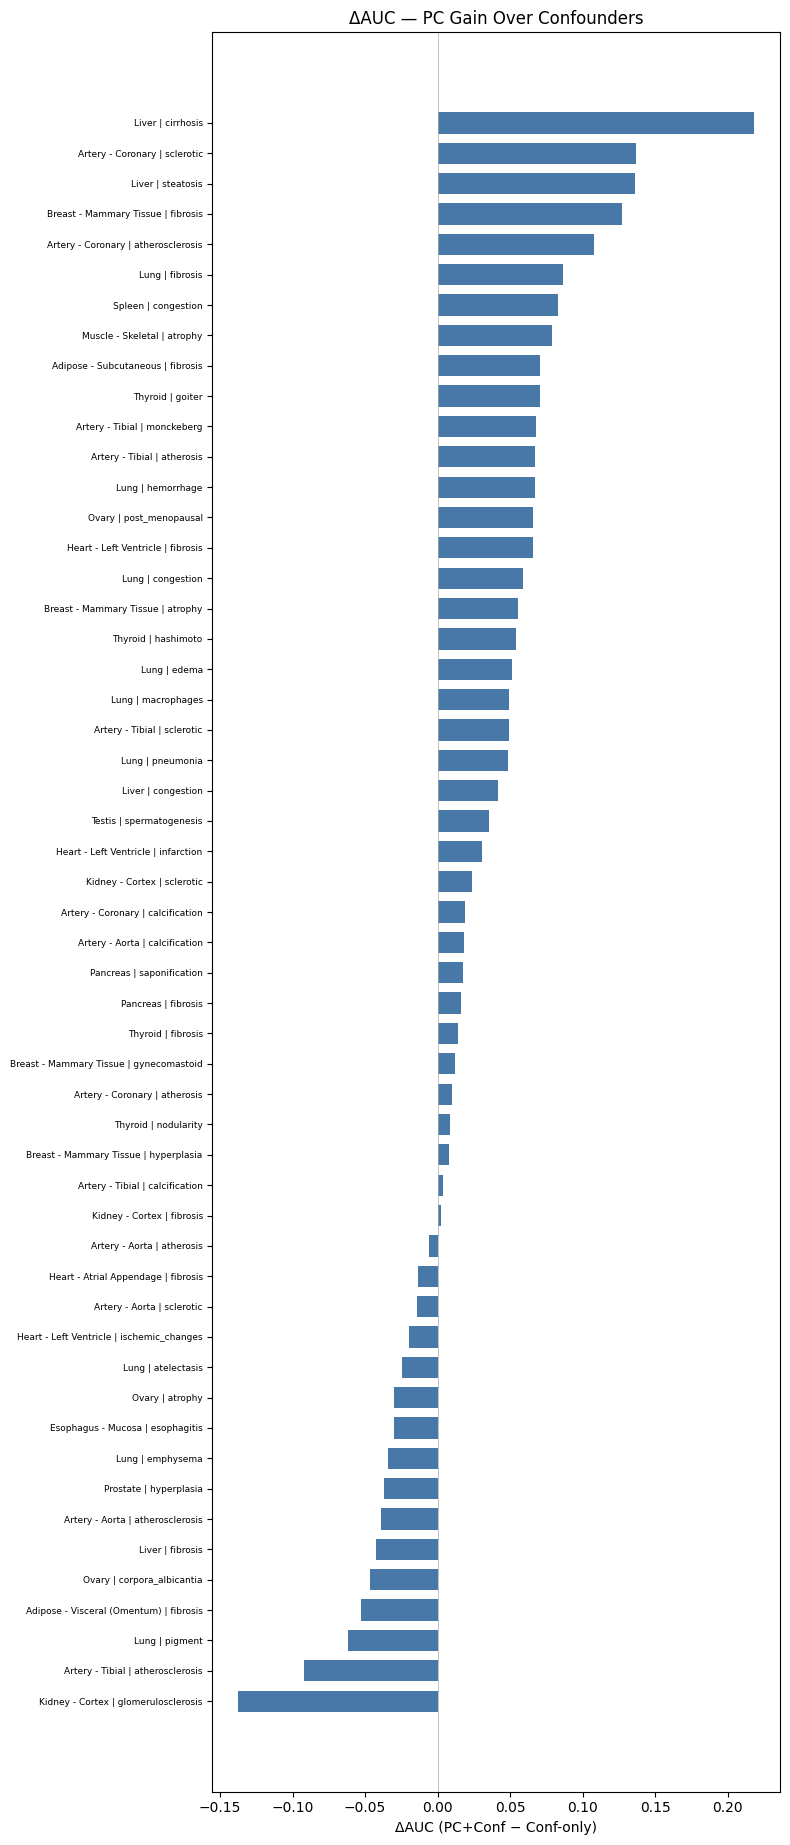

In [11]:
delta_df = comp[['tissue', 'category', 'auc_pc', 'auc_pc_conf', 'auc_conf', 'delta_pc']].copy()

print(f'Mean Δ (PC gain over conf): {delta_df["delta_pc"].mean():.4f}')

_ = plot_delta_bar(
    delta_df, delta_col='delta_pc',
    title='ΔAUC — PC Gain Over Confounders',
    xlabel='ΔAUC (PC+Conf − Conf-only)',
    save_path=Config.FIGURES_DIR / 'delta_auc_pc_over_conf.pdf'
)

## 10.9 — Export

In [12]:
# Save with delta column
export_df = comp[['tissue', 'category', 'auc_pc', 'auc_pc_conf', 'auc_conf', 'delta_pc']].copy()
export_df['label'] = export_df['tissue'] + ' | ' + export_df['category']
export_df = export_df.sort_values('delta_pc', ascending=False).reset_index(drop=True)
export_df.to_csv(Config.TABLES_DIR / 'pc_auc_results.csv', index=False)
print(f'Saved {len(export_df)} rows → output/tables/pc_auc_results.csv')
display(export_df)

Saved 53 rows → output/tables/pc_auc_results.csv


,tissue,category,auc_pc,auc_pc_conf,auc_conf,delta_pc,label
0,Liver,cirrhosis,0.780424,0.785191,0.566866,0.218326,Liver | cirrhosis
1,Artery - Coronary,sclerotic,0.581211,0.583715,0.446685,0.137030,Artery - Coronary | sclerotic
2,Liver,steatosis,0.639692,0.644392,0.508159,0.136233,Liver | steatosis
3,Breast - Mammary Tissue,fibrosis,0.529496,0.530893,0.403861,0.127033,Breast - Mammary Tissue | fibrosis
4,Artery - Coronary,atherosclerosis,0.519136,0.511413,0.403631,0.107782,Artery - Coronary | atherosclerosis
5,Lung,fibrosis,0.542679,0.537658,0.451357,0.086301,Lung | fibrosis
6,Spleen,congestion,0.794658,0.803827,0.720674,0.083153,Spleen | congestion
7,Muscle - Skeletal,atrophy,0.664583,0.697917,0.618750,0.079167,Muscle - Skeletal | atrophy
8,Adipose - Subcutaneous,fibrosis,0.556944,0.576630,0.506039,0.070592,Adipose - Subcutaneous | fibrosis
9,Thyroid,goiter,0.591779,0.599483,0.529107,0.070375,Thyroid | goiter


In [14]:
print(f"Qualifying models: {((comp['auc_pc_conf'] >= 0.60) & (comp['delta_pc'] >= 0.05)).sum()}")


Qualifying models: 9
